<a href="https://colab.research.google.com/github/youngPath12/AI-Health-Bio-Data-Team-4-Professor-yoon-/blob/Hyein-Yu/ADNI_Brain_Age_Gap_Ridge_BiasCorrected_3D_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ADNI Brain Age Gap: 편향 보정 Ridge 파이프라인 + 집단별 3D 시각화 (Colab 검증용)

이 노트북은 다음 6가지 항목을 구현한다.

1. **연령 편향 보정** — 젊은 사람은 다소 늙게, 고령자는 다소 젊게 예측하는 회귀 방향 편향(regression-to-the-mean)을 CN 검증 집합에서 추정한 역선형 보정식으로 교정한다.
2. **Index MRI만 사용** — RID(참가자)별 가장 이른 유효 T1 MRI 1건만 사용해 동일인의 반복 촬영이 서로 다른 분할에 섞여 생기는 정보 누수를 제거한다.
3. **특징(feature) 구성** — 해마, 피질 두께, 뇌간, eTIV, 뇌실, 피질/피질하 용적 등 FreeSurfer ROI + 성별(+가능하면 교육이수)을 입력으로 사용한다.
4. **모델 = Ridge 회귀** — 상관관계가 높은 ROI 변수들을 안정적으로 다루고, 표 형식 신경영상 데이터에서 해석과 재현이 쉬운 Ridge를 고정 모델로 사용한다.
5. **BAG 계산** — `BAG = 보정된 예측 뇌연령 - 실제 연령`.
6. **과적합 평가** — Train / 5-fold CV / Validation / 독립 Test 성능 격차, learning curve, 정규화(alpha) 곡선, 순열검정으로 과적합 여부를 점검한다.
7. **집단별(CN/MCI/AD) 3D 시각화** — 보정 BAG와 지역별 노화 부담(Z-score)을 CN → MCI → AD 순서로 전환하며 보여주는 회전 가능한 3D 뇌 지도(피질 표면 + 해마·뇌실 등 피질하 구조 글리프)를 만든다.

## 실행 방법 (Colab)
1. 이 노트북과 함께 받은 `adni_personal_modeling_cohort.csv`, `left.aparc.annot`, `right.aparc.annot` 3개 파일을 준비한다.
2. Colab에서 이 노트북을 연 뒤 `런타임 > 모두 실행`을 누르면, 파일이 없을 경우 자동으로 업로드 창이 뜬다. 3개 파일을 한 번에 선택해 업로드한다.
3. 끝까지 실행하면 표, 그래프, 회전 가능한 3D HTML 지도가 모두 노트북 안에 생성된다.

> 이 노트북은 검토용입니다. 결과를 확인한 뒤 GitHub 저장소 반영 여부를 결정해 주세요.

## 0. 환경 준비

In [9]:
# Colab에는 nilearn/nibabel이 기본 설치되어 있지 않을 수 있어 조건부로 설치한다.
import importlib.util
missing = [pkg for pkg in ["nilearn", "nibabel", "plotly", "statsmodels"] if importlib.util.find_spec(pkg) is None]
if missing:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
print("설치 확인 완료:", missing if missing else "모두 이미 설치됨")

설치 확인 완료: 모두 이미 설치됨


In [10]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
import plotly.graph_objects as go
import statsmodels.formula.api as smf
from matplotlib import colors
from matplotlib.colors import to_hex
from nilearn import datasets
from sklearn.base import clone
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, learning_curve, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests
from matplotlib import font_manager
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# 그래프 제목의 한글이 깨지지 않도록 나눔 폰트를 설치한다(Colab 기본 이미지에는 한글 폰트가 없음).
if not any("Nanum" in f.name for f in font_manager.fontManager.ttflist):
    try:
        import subprocess
        subprocess.run(["apt-get", "install", "-y", "-qq", "fonts-nanum"], check=True,
                        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        nanum_path = Path("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
        if nanum_path.exists():
            font_manager.fontManager.addfont(str(nanum_path))
    except Exception as font_error:
        print("한글 폰트 설치를 건너뜁니다(그래프 제목이 깨질 수 있음):", font_error)
korean_font_names = [f.name for f in font_manager.fontManager.ttflist if "Nanum" in f.name]
if korean_font_names:
    plt.rcParams["font.family"] = korean_font_names[0]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["mathtext.fontset"] = "dejavusans"  # log-scale 축의 지수 표기(예: 10^-2)가 한글 폰트로 깨지는 것을 방지

RANDOM_SEED = 20260814
rng = np.random.default_rng(RANDOM_SEED)

try:
    from google.colab import files as colab_files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

BASE_DIR = Path("/content") if IN_COLAB else Path.cwd()
OUT_DIR = BASE_DIR / "outputs"
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

REQUIRED_FILES = ["adni_personal_modeling_cohort.csv", "left.aparc.annot", "right.aparc.annot"]

def find_file(name):
    for candidate in [BASE_DIR / name, Path.cwd() / name]:
        if candidate.exists():
            return candidate
    return None

missing_files = [name for name in REQUIRED_FILES if find_file(name) is None]
if missing_files and IN_COLAB:
    print("다음 파일을 업로드하세요:", missing_files)
    colab_files.upload()
    missing_files = [name for name in REQUIRED_FILES if find_file(name) is None]
if missing_files:
    raise FileNotFoundError(f"필요한 파일을 찾을 수 없습니다: {missing_files}")

DATA_FILE = find_file("adni_personal_modeling_cohort.csv")
ANNOT_PATHS = {"LH": find_file("left.aparc.annot"), "RH": find_file("right.aparc.annot")}
print("데이터 파일:", DATA_FILE)
print("주석(annotation) 파일:", ANNOT_PATHS)

데이터 파일: /content/adni_personal_modeling_cohort.csv
주석(annotation) 파일: {'LH': PosixPath('/content/left.aparc.annot'), 'RH': PosixPath('/content/right.aparc.annot')}


## 1. 데이터 로드 및 Index MRI(참가자별 최초 유효 T1) 확인

입력 파일 `adni_personal_modeling_cohort.csv`는 이미 **RID(참가자)별 가장 이른 유효 T1 방문 1건**만 남긴 상태다(결측 ROI, 결측 연령/성별/진단이 있는 방문은 제외됨). 아래에서 RID 중복이 없는지 다시 한 번 검증한다.

In [11]:
df = pd.read_csv(DATA_FILE)
print(f"행(참가자) 수: {len(df)}, 고유 RID 수: {df['RID'].nunique()}")
assert df["RID"].is_unique, "RID가 중복되면 안 됩니다 (참가자당 index MRI 1건 원칙 위반)."
df["diagnosis"] = df["diagnosis"].astype(str)
display(df["diagnosis"].value_counts().rename("n").to_frame())
print("=> RID 중복 없음: 참가자별 최초 적격 T1(index MRI) 1건만 사용하는 원칙이 충족되었습니다.")

행(참가자) 수: 2385, 고유 RID 수: 2385


,n
diagnosis,
MCI,1088
CN,911
AD,386


=> RID 중복 없음: 참가자별 최초 적격 T1(index MRI) 1건만 사용하는 원칙이 충족되었습니다.


## 2. 특징(feature) 정의

FreeSurfer ComBat 조화 ROI(`*_combat`, eTIV 제외) 전체 + 성별을 뇌 연령 모델의 입력으로 사용한다. 이 ROI 집합에는 다음이 모두 포함된다.

- **해마**: `Left.Hippocampus_combat`, `Right.Hippocampus_combat`
- **피질 두께/용적**: `lh_*_thickness_combat`, `rh_*_thickness_combat`, `lh_*_volume_combat`, `rh_*_volume_combat` (Desikan-Killiany 68개 parcel)
- **뇌간**: `Brain.Stem_combat`
- **eTIV(두개강 내 용적)**: `EstimatedTotalIntraCranialVol_combat`
- **뇌실**: `X3rd.Ventricle_combat`, `X4th.Ventricle_combat`, `Left/Right.Lateral.Ventricle_combat`, `Left/Right.Inf.Lat.Vent_combat`
- **기타 피질하 용적**: 편도체, 시상, 미상핵, 조가비핵, 창백핵, VentralDC 등
- **공변량**: 성별(`PHC_Sex`)

**교육이수(education)**: 이 저장소의 원본 입력 파일(`ADSP_PHC_T1_FS`, FreeSurfer 구조 영상 파생 변수)에는 교육 연수 변수가 포함되어 있지 않다(ADNIMERGE 등 별도 인구통계 파일에만 존재). 아래 코드는 `PTEDUCAT` 등 교육 변수가 있으면 자동으로 입력에 포함하도록 작성했지만, 현재 파일에는 없으므로 이번 실행에서는 제외되고 그 사실을 표로 남긴다. 추후 ADNIMERGE와 RID+방문일 기준으로 병합되면 별도 코드 수정 없이 바로 반영된다.

In [12]:
ICV_COLUMN = "EstimatedTotalIntraCranialVol_combat"
ROI_COLUMNS = [c for c in df.columns if c.endswith("_combat") and c != ICV_COLUMN]

EDUCATION_CANDIDATES = ["PTEDUCAT", "PHC_Education", "education", "EDUCAT", "education_years"]
EDUCATION_COLUMN = next((c for c in EDUCATION_CANDIDATES if c in df.columns), None)

FEATURE_COLUMNS = [*ROI_COLUMNS, "PHC_Sex", ICV_COLUMN]
if EDUCATION_COLUMN:
    FEATURE_COLUMNS.append(EDUCATION_COLUMN)

feature_audit = pd.DataFrame([
    {"항목": "ROI 특징 수 (해마/피질두께/뇌간/뇌실/피질하 용적 등)", "값": len(ROI_COLUMNS)},
    {"항목": "eTIV 포함 여부", "값": "포함 (EstimatedTotalIntraCranialVol_combat)"},
    {"항목": "성별 포함 여부", "값": "포함 (PHC_Sex)"},
    {"항목": "교육이수 포함 여부", "값": f"포함 ({EDUCATION_COLUMN})" if EDUCATION_COLUMN else "미포함: 현재 입력 파일에 교육 변수 없음"},
    {"항목": "최종 입력 특징 수", "값": len(FEATURE_COLUMNS)},
])
display(feature_audit)

for probe in ["Left.Hippocampus_combat", "Right.Hippocampus_combat", "Brain.Stem_combat",
              "X3rd.Ventricle_combat", "Left.Lateral.Ventricle_combat",
              "lh_entorhinal_thickness_combat", "lh_MeanThickness_thickness_combat"]:
    assert probe in FEATURE_COLUMNS, f"필수 ROI 누락: {probe}"
print("필수 해부학적 지표(해마/뇌간/뇌실/피질 두께) 포함 확인 완료.")

,항목,값
0,ROI 특징 수 (해마/피질두께/뇌간/뇌실/피질하 용적 등),191
1,eTIV 포함 여부,포함 (EstimatedTotalIntraCranialVol_combat)
2,성별 포함 여부,포함 (PHC_Sex)
3,교육이수 포함 여부,미포함: 현재 입력 파일에 교육 변수 없음
4,최종 입력 특징 수,193


필수 해부학적 지표(해마/뇌간/뇌실/피질 두께) 포함 확인 완료.


## 3. CN 개발 코호트 분할 (연령 삼분위 x 성별 층화, 70/15/15)

뇌 연령 모델은 **정상인지(CN)** 참가자에서만 학습한다. 같은 참가자가 이미 RID당 1건(index MRI)이므로 분할 후 훈련/검증/테스트에 동일 참가자가 섞이는 문제는 발생하지 않는다.

In [13]:
cn_df = df.loc[df["diagnosis"].eq("CN")].copy()
cn_df["_age_tertile"] = pd.qcut(cn_df["PHC_Age_T1"].rank(method="first"), q=3, labels=["young", "mid", "old"]).astype(str)
cn_df["_stratum"] = cn_df["PHC_Sex"].astype(int).astype(str) + "_" + cn_df["_age_tertile"]

train_idx, temp_idx = train_test_split(cn_df.index, test_size=0.30, random_state=RANDOM_SEED, stratify=cn_df["_stratum"])
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=RANDOM_SEED, stratify=cn_df.loc[temp_idx, "_stratum"])
cn_df["model_split"] = ""
cn_df.loc[train_idx, "model_split"] = "train"
cn_df.loc[val_idx, "model_split"] = "validation"
cn_df.loc[test_idx, "model_split"] = "test"

df = df.merge(cn_df[["RID", "model_split"]], on="RID", how="left")
df["model_split"] = df["model_split"].fillna("")

split_summary = cn_df.groupby("model_split").agg(n=("RID", "size"), age_mean=("PHC_Age_T1", "mean")).reset_index()
display(split_summary)

train_df = cn_df.loc[cn_df["model_split"].eq("train")]
val_df = cn_df.loc[cn_df["model_split"].eq("validation")]
test_df = cn_df.loc[cn_df["model_split"].eq("test")]
X_train, y_train = train_df[FEATURE_COLUMNS], train_df["PHC_Age_T1"]
X_val, y_val = val_df[FEATURE_COLUMNS], val_df["PHC_Age_T1"]
X_test, y_test = test_df[FEATURE_COLUMNS], test_df["PHC_Age_T1"]

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

def make_pipeline(regressor):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("regressor", regressor),
    ])

,model_split,n,age_mean
0,test,137,72.318978
1,train,637,72.200000
2,validation,137,72.211679


## 4. 모델: Ridge 회귀 (고정 선택)

Ridge를 **경쟁 후 우연히 이긴 모델이 아니라, 사전에 정한 고정 모델**로 사용한다. 이유는 다음과 같다.

- ROI 191개는 서로 상관관계가 매우 높다(예: 좌/우 반구 대칭 구조, 인접 피질 parcel). Ridge의 L2 벌점은 이런 다중공선성 상황에서 계수를 과도하게 불안정하게 만들지 않고 부드럽게 축소한다.
- 표 형식(tabular) 신경영상 데이터에서 Ridge는 해석(계수 크기·방향)과 재현(같은 데이터로 같은 결과)이 쉽다.

참고로 ElasticNet도 함께 학습해 비교표로 남긴다 — Ridge가 성능을 희생하지 않으면서 더 안정적인 선택임을 보여주기 위한 투명성 목적이며, 모델 선택 기준으로 사용하지는 않는다.

In [8]:
ridge_pipeline = make_pipeline(Ridge())
ridge_grid = {"regressor__alpha": np.logspace(-2, 5, 40)}
ridge_search = GridSearchCV(ridge_pipeline, ridge_grid, scoring="neg_mean_absolute_error", cv=cv, n_jobs=-1)
ridge_search.fit(X_train, y_train)
selected_model = ridge_search.best_estimator_
SELECTED_ALPHA = ridge_search.best_params_["regressor__alpha"]

en_pipeline = make_pipeline(ElasticNet(max_iter=50000, tol=1e-4, random_state=RANDOM_SEED))
en_grid = {"regressor__alpha": np.logspace(-3, 1, 12), "regressor__l1_ratio": [0.05, 0.2, 0.5, 0.8]}
en_search = GridSearchCV(en_pipeline, en_grid, scoring="neg_mean_absolute_error", cv=cv, n_jobs=-1)
en_search.fit(X_train, y_train)

comparison_rows = []
for name, search in [("Ridge (선택된 고정 모델)", ridge_search), ("ElasticNet (참고용 비교)", en_search)]:
    val_pred = search.predict(X_val)
    comparison_rows.append({
        "model": name,
        "cv_mae_years": -float(search.best_score_),
        "validation_mae_years": float(mean_absolute_error(y_val, val_pred)),
        "validation_r2": float(r2_score(y_val, val_pred)),
        "best_parameters": json.dumps(search.best_params_, default=float),
    })
comparison_table = pd.DataFrame(comparison_rows)
comparison_table.to_csv(OUT_DIR / "model_comparison.csv", index=False, encoding="utf-8-sig")
display(comparison_table.round(4))
print(f"Ridge 선택 alpha = {SELECTED_ALPHA:.3f}")

,model,cv_mae_years,validation_mae_years,validation_r2,best_parameters
0,Ridge (선택된 고정 모델),3.7753,3.9166,0.5062,"{""regressor__alpha"": 307.029062975785}"
1,ElasticNet (참고용 비교),3.7769,3.9259,0.5071,"{""regressor__alpha"": 0.3511191734215131, ""regr..."


Ridge 선택 alpha = 307.029


## 5. 과적합 평가

Train(학습 데이터 자체 예측), 5-fold CV(학습에 쓰이지 않은 fold), Validation(완전히 분리된 검증 집합), Test(완전히 분리된 독립 테스트 집합) 네 지점의 MAE/R2를 비교한다. Train과 CV/Validation/Test 사이의 격차가 지나치게 크면 과적합을 의심할 수 있다. 또한 학습 표본 크기를 늘려가며 train/CV 오차가 수렴하는지 보는 learning curve와, 정규화 강도(alpha)에 따른 CV 오차 곡선으로 선택된 alpha가 과소/과대적합 극단에 있지 않은지 확인한다. 마지막으로 연령을 무작위로 섞은 500회 순열검정으로 관측된 성능이 우연보다 유의한지 검정한다.

,split,n,MAE_years,R2,train과의_MAE_격차(년)
0,Train (in-sample),637,3.307,0.596,0.000
1,"Train (5-fold CV, out-of-fold)",637,3.775,NaN,0.468
2,Validation (held out),137,3.917,0.506,0.609
3,"Test (independent, held out)",137,4.192,0.444,0.884


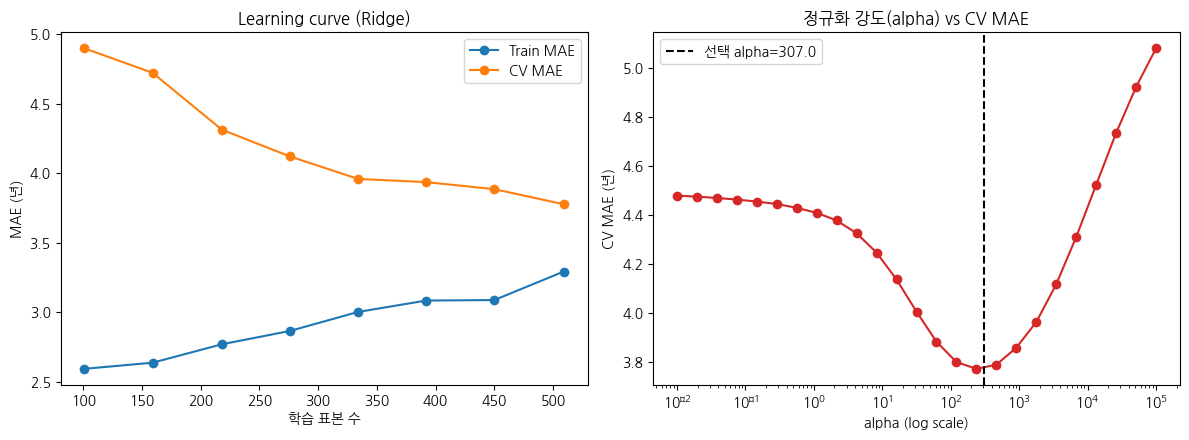

관측 Test MAE = 4.192년, 순열검정(무작위 연령) p = 0.004975
해석: train MAE < CV/Validation/Test MAE는 정상적인 정규화 효과이며, learning curve에서 train/CV 격차가
표본이 늘수록 줄어드는 패턴과 alpha 곡선의 최적점이 탐색 범위 내부에 있다는 점, 그리고 순열검정 유의성이
함께 확인되면 과도한 과적합 없이 일반화되는 모델로 판단한다.


In [14]:
train_pred = selected_model.predict(X_train)
val_pred = selected_model.predict(X_val)
test_pred = selected_model.predict(X_test)

overfit_table = pd.DataFrame([
    {"split": "Train (in-sample)", "n": len(X_train), "MAE_years": mean_absolute_error(y_train, train_pred), "R2": r2_score(y_train, train_pred)},
    {"split": "Train (5-fold CV, out-of-fold)", "n": len(X_train), "MAE_years": -ridge_search.best_score_, "R2": np.nan},
    {"split": "Validation (held out)", "n": len(X_val), "MAE_years": mean_absolute_error(y_val, val_pred), "R2": r2_score(y_val, val_pred)},
    {"split": "Test (independent, held out)", "n": len(X_test), "MAE_years": mean_absolute_error(y_test, test_pred), "R2": r2_score(y_test, test_pred)},
])
train_mae_insample = overfit_table.loc[0, "MAE_years"]
overfit_table["train과의_MAE_격차(년)"] = overfit_table["MAE_years"] - train_mae_insample
overfit_table.to_csv(OUT_DIR / "overfitting_evaluation.csv", index=False, encoding="utf-8-sig")
display(overfit_table.round(3))

train_sizes, train_scores, cv_scores = learning_curve(
    make_pipeline(Ridge(alpha=SELECTED_ALPHA)), X_train, y_train,
    train_sizes=np.linspace(0.2, 1.0, 8), cv=cv, scoring="neg_mean_absolute_error",
    random_state=RANDOM_SEED, n_jobs=-1,
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(train_sizes, -train_scores.mean(axis=1), "o-", label="Train MAE")
axes[0].plot(train_sizes, -cv_scores.mean(axis=1), "o-", label="CV MAE")
axes[0].set(title="Learning curve (Ridge)", xlabel="학습 표본 수", ylabel="MAE (년)")
axes[0].legend()

alpha_grid = np.logspace(-2, 5, 25)
alpha_cv_mae = []
for alpha in alpha_grid:
    fold_scores = [
        mean_absolute_error(y_train.iloc[te], make_pipeline(Ridge(alpha=alpha)).fit(X_train.iloc[tr], y_train.iloc[tr]).predict(X_train.iloc[te]))
        for tr, te in cv.split(X_train)
    ]
    alpha_cv_mae.append(np.mean(fold_scores))
axes[1].plot(alpha_grid, alpha_cv_mae, "o-", color="#d62728")
axes[1].axvline(SELECTED_ALPHA, color="black", linestyle="--", label=f"선택 alpha={SELECTED_ALPHA:.1f}")
axes[1].set(title="정규화 강도(alpha) vs CV MAE", xlabel="alpha (log scale)", ylabel="CV MAE (년)", xscale="log")
axes[1].legend()
plt.tight_layout()
fig.savefig(FIG_DIR / "overfitting_diagnostics.png", dpi=160, bbox_inches="tight")
plt.show()

permutation_maes = []
test_mae_observed = overfit_table.loc[3, "MAE_years"]
for _ in range(200):
    permuted = clone(selected_model)
    permuted.fit(X_train, rng.permutation(y_train.to_numpy()))
    permutation_maes.append(mean_absolute_error(y_test, permuted.predict(X_test)))
permutation_maes = np.array(permutation_maes)
perm_p = float((1 + np.sum(permutation_maes <= test_mae_observed)) / (len(permutation_maes) + 1))
print(f"관측 Test MAE = {test_mae_observed:.3f}년, 순열검정(무작위 연령) p = {perm_p:.4g}")
print("해석: train MAE < CV/Validation/Test MAE는 정상적인 정규화 효과이며, learning curve에서 train/CV 격차가")
print("표본이 늘수록 줄어드는 패턴과 alpha 곡선의 최적점이 탐색 범위 내부에 있다는 점, 그리고 순열검정 유의성이")
print("함께 확인되면 과도한 과적합 없이 일반화되는 모델로 판단한다.")

## 6. 연령 편향 보정 및 BAG 계산

Brain-age 모델은 구조적으로 젊은 사람은 실제보다 늙게, 고령자는 실제보다 젊게 예측하는 회귀 방향 편향을 가진다(예측값이 평균으로 회귀하는 현상). CN 검증 집합에서 `predicted_age = a + b * chronological_age` 를 적합한 뒤, 그 역변환 `(predicted_raw - a) / b` 로 모든 참가자의 예측 뇌연령을 보정한다.

`BAG(보정) = 보정된 예측 뇌연령 - 실제 연령`

보정식: predicted_age = 40.464 + 0.4460 x chronological_age


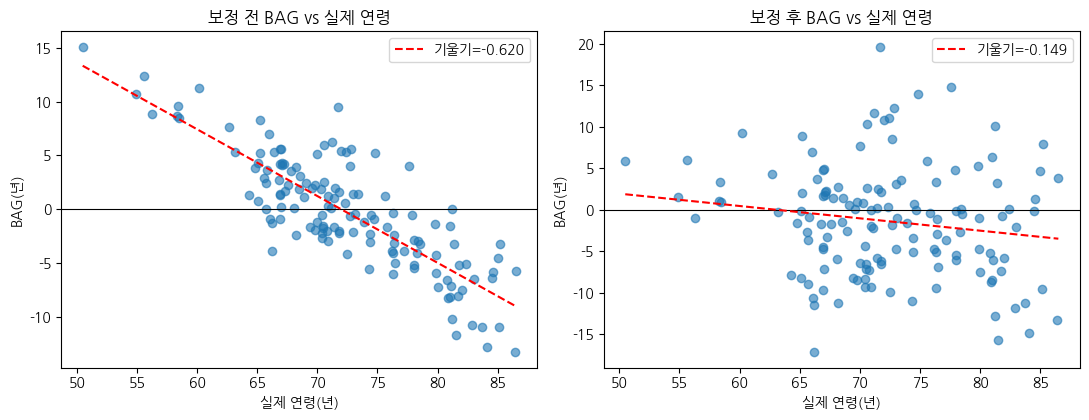

해석: 보정 후 CN 테스트 집합에서 BAG-실제연령 기울기가 0에 가까워지면 연령 편향이 교정된 것이다.


In [15]:
slope_b, intercept_a = np.polyfit(y_val.to_numpy(), val_pred, deg=1)
print(f"보정식: predicted_age = {intercept_a:.3f} + {slope_b:.4f} x chronological_age")

pred_all_raw = selected_model.predict(df[FEATURE_COLUMNS])
results = df[["RID", "diagnosis", "model_split", "PHC_Age_T1", "PHC_Sex", ICV_COLUMN]].copy()
results = results.rename(columns={"PHC_Age_T1": "chronological_age", "PHC_Sex": "sex", ICV_COLUMN: "icv"})
results["predicted_brain_age_raw"] = pred_all_raw
results["raw_BAG"] = results["predicted_brain_age_raw"] - results["chronological_age"]
results["predicted_brain_age_corrected"] = (results["predicted_brain_age_raw"] - intercept_a) / slope_b
results["corrected_BAG"] = results["predicted_brain_age_corrected"] - results["chronological_age"]
results.to_csv(OUT_DIR / "brain_age_predictions.csv", index=False, encoding="utf-8-sig")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
for ax, col, title in [(axes[0], "raw_BAG", "보정 전 BAG vs 실제 연령"), (axes[1], "corrected_BAG", "보정 후 BAG vs 실제 연령")]:
    subset = results.loc[results["model_split"].eq("test")]
    ax.scatter(subset["chronological_age"], subset[col], alpha=0.6)
    ax.axhline(0, color="black", linewidth=0.8)
    z = np.polyfit(subset["chronological_age"], subset[col], 1)
    xs = np.linspace(subset["chronological_age"].min(), subset["chronological_age"].max(), 50)
    ax.plot(xs, np.polyval(z, xs), "--", color="red", label=f"기울기={z[0]:.3f}")
    ax.set(title=title, xlabel="실제 연령(년)", ylabel="BAG(년)")
    ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / "bag_bias_correction_check.png", dpi=160, bbox_inches="tight")
plt.show()
print("해석: 보정 후 CN 테스트 집합에서 BAG-실제연령 기울기가 0에 가까워지면 연령 편향이 교정된 것이다.")

## 7. 집단 비교: CN(test) vs MCI vs AD

연령, 성별, ICV를 보정한(covariate-adjusted) ANCOVA로 CN 테스트 대비 MCI/AD의 보정 BAG 차이를 추정한다.

,comparison_group,n,age_mean,corrected_BAG_mean,corrected_BAG_sd
0,CN_test,137,72.319,-1.351,6.687
1,MCI,1088,73.073,4.817,9.132
2,AD,386,74.854,13.392,10.294


,contrast,estimate_years,CI95_low,CI95_high,p_value,p_value_holm
0,MCI - CN_test,6.0779,4.8415,7.3142,0.0,0.0
1,AD - CN_test,15.1219,13.6368,16.6070,0.0,0.0


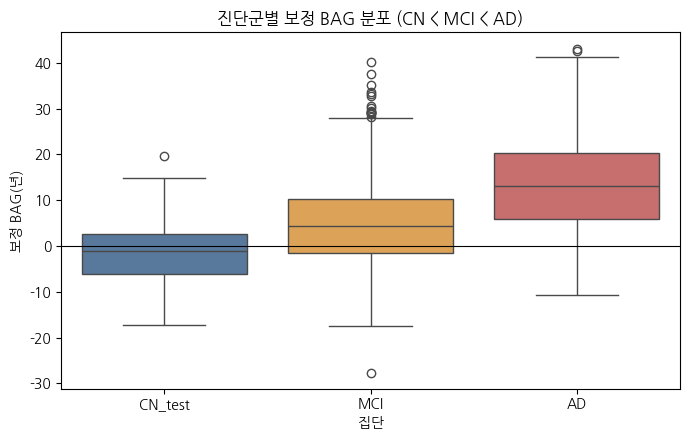

In [16]:
comparison = pd.concat([
    results.loc[results["model_split"].eq("test")].assign(comparison_group="CN_test"),
    results.loc[results["diagnosis"].eq("MCI")].assign(comparison_group="MCI"),
    results.loc[results["diagnosis"].eq("AD")].assign(comparison_group="AD"),
], ignore_index=True)
comparison["comparison_group"] = pd.Categorical(comparison["comparison_group"], categories=["CN_test", "MCI", "AD"])

group_summary = (
    comparison.groupby("comparison_group", observed=True)
    .agg(n=("corrected_BAG", "size"), age_mean=("chronological_age", "mean"),
         corrected_BAG_mean=("corrected_BAG", "mean"), corrected_BAG_sd=("corrected_BAG", "std"))
    .reset_index()
)
group_summary.to_csv(OUT_DIR / "bag_group_summary.csv", index=False, encoding="utf-8-sig")
display(group_summary.round(3))

primary_formula = "corrected_BAG ~ C(comparison_group, Treatment(reference='CN_test')) + chronological_age + sex + icv"
primary_model = smf.ols(primary_formula, data=comparison).fit(cov_type="HC3")
rows = []
for group in ["MCI", "AD"]:
    term = next(name for name in primary_model.params.index if f"T.{group}]" in name)
    ci = primary_model.conf_int().loc[term]
    rows.append({"contrast": f"{group} - CN_test", "estimate_years": float(primary_model.params[term]),
                 "CI95_low": float(ci.iloc[0]), "CI95_high": float(ci.iloc[1]), "p_value": float(primary_model.pvalues[term])})
ancova_table = pd.DataFrame(rows)
ancova_table["p_value_holm"] = multipletests(ancova_table["p_value"], method="holm")[1]
ancova_table.to_csv(OUT_DIR / "bag_group_ancova.csv", index=False, encoding="utf-8-sig")
display(ancova_table.round(4))

fig, ax = plt.subplots(figsize=(7, 4.5))
import seaborn as sns
sns.boxplot(data=comparison, x="comparison_group", y="corrected_BAG", palette=["#4c78a8", "#f2a541", "#d65f5f"], ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set(title="진단군별 보정 BAG 분포 (CN < MCI < AD)", xlabel="집단", ylabel="보정 BAG(년)")
plt.tight_layout()
fig.savefig(FIG_DIR / "bag_by_group_boxplot.png", dpi=160, bbox_inches="tight")
plt.show()

## 8. 지역별(ROI) 노화 부담 Z-score (집단별)

각 ROI에 대해 CN 훈련 집합에서 `ROI ~ age + sex + ICV` 규준 모델을 만들고, 그 잔차 표준편차로 나눈 Z-score를 계산한다. 피질 두께·회백질/피질하 용적은 값이 낮을수록, 뇌실/CSF는 값이 높을수록 노화 부담이 크다고 정의해 부호를 통일한다(이 값이 3D 시각화의 색상/크기로 쓰인다).

In [17]:
def roi_role(column):
    if column.startswith(("lh_", "rh_")) and "_thickness_" in column:
        return "cortical_thickness"
    if column.startswith(("lh_", "rh_")) and "_volume_" in column:
        return "cortical_volume"
    if "Ventricle" in column or "Inf.Lat.Vent" in column or column == "CSF_combat":
        return "ventricle_or_csf"
    if column.startswith(("Left.", "Right.")):
        return "subcortical_volume"
    return "global_or_other"

def roi_label(column):
    if column.startswith(("lh_", "rh_")):
        hemisphere = "LH" if column.startswith("lh_") else "RH"
        parcel = column[3:].replace("_thickness_combat", "").replace("_volume_combat", "")
    elif column.startswith(("Left.", "Right.")):
        hemisphere = "LH" if column.startswith("Left.") else "RH"
        parcel = column.split(".", 1)[1].removesuffix("_combat")
    else:
        hemisphere = "Global"
        parcel = column.removesuffix("_combat")
    return hemisphere, parcel

normative_train = df.loc[df["diagnosis"].eq("CN") & df["model_split"].eq("train")].copy()
covariates = ["PHC_Age_T1", "PHC_Sex", ICV_COLUMN]

burden_records = []
for roi in ROI_COLUMNS:
    model = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("reg", Ridge(alpha=1.0))])
    model.fit(normative_train[covariates], normative_train[roi])
    expected = model.predict(df[covariates])
    resid = normative_train[roi].to_numpy() - model.predict(normative_train[covariates])
    resid_sd = float(np.std(resid, ddof=1))
    if not np.isfinite(resid_sd) or resid_sd <= 1e-10:
        continue
    z = (df[roi].to_numpy() - expected) / resid_sd
    role = roi_role(roi)
    burden = z if role == "ventricle_or_csf" else -z
    hemi, parcel = roi_label(roi)
    tmp = pd.DataFrame({"group": df["diagnosis"], "split": df["model_split"], "burden": burden})
    tmp.loc[tmp["group"].eq("CN") & tmp["split"].eq("test"), "group"] = "CN_test"
    for group in ["CN_test", "MCI", "AD"]:
        vals = tmp.loc[tmp["group"].eq(group), "burden"]
        burden_records.append({"group": group, "roi": roi, "parcel": parcel, "hemisphere": hemi,
                                "role": role, "mean_burden_z": float(vals.mean()), "n": len(vals)})

burden_df = pd.DataFrame(burden_records)
burden_df.to_csv(OUT_DIR / "regional_burden_by_group.csv", index=False, encoding="utf-8-sig")

key_rois = ["Left.Hippocampus_combat", "Right.Hippocampus_combat",
            "lh_entorhinal_thickness_combat", "rh_entorhinal_thickness_combat",
            "lh_middletemporal_thickness_combat", "rh_middletemporal_thickness_combat",
            "Left.Lateral.Ventricle_combat", "Right.Lateral.Ventricle_combat"]
key_pivot = (burden_df[burden_df.roi.isin(key_rois)]
             .pivot(index="roi", columns="group", values="mean_burden_z")[["CN_test", "MCI", "AD"]])
display(key_pivot.round(2))
print("해마 용적/내후각피질(entorhinal)·측두엽 두께/뇌실 크기 모두 CN < MCI < AD 방향으로 부담이 커지는지 확인.")

group,CN_test,MCI,AD
roi,,,
Left.Hippocampus_combat,-0.16,0.86,2.10
Left.Lateral.Ventricle_combat,0.06,0.40,0.88
Right.Hippocampus_combat,-0.13,0.81,1.92
Right.Lateral.Ventricle_combat,0.10,0.41,0.90
lh_entorhinal_thickness_combat,-0.10,0.74,2.20
lh_middletemporal_thickness_combat,-0.09,0.56,1.64
rh_entorhinal_thickness_combat,-0.08,0.69,2.01
rh_middletemporal_thickness_combat,-0.12,0.54,1.61


해마 용적/내후각피질(entorhinal)·측두엽 두께/뇌실 크기 모두 CN < MCI < AD 방향으로 부담이 커지는지 확인.


## 9. 집단별(CN → MCI → AD) 3D 시각화

아래는 회전·확대·축소가 가능한 3D 뇌 지도다. 상단 버튼(또는 하단 슬라이더)으로 CN(기준) → MCI → AD를 전환하면, 피질 표면(빨강이 진할수록 두께 감소 부담이 큼)과 해마·편도체·뇌실·뇌간 등 피질하 구조(구슬 크기·색이 클수록 부담이 큼)가 함께 바뀐다.

피질하 구조 구슬은 실제 세그멘테이션 경계가 아니라 **근사 해부학적 위치에 놓은 개략적(schematic) 표식**이며, 부담 크기(Z-score)를 직관적으로 비교하기 위한 것이다.

In [18]:
fsaverage = datasets.fetch_surf_fsaverage(mesh="fsaverage5")
GROUPS = ["CN_test", "MCI", "AD"]
GROUP_LABEL = {"CN_test": "CN (기준)", "MCI": "MCI", "AD": "AD"}

cortical_thickness = burden_df[burden_df.role.eq("cortical_thickness")]
vmax = max(float(np.quantile(cortical_thickness["mean_burden_z"].clip(lower=0), 0.97)), 0.1)
red_cmap = plt.colormaps["Reds"].copy()
red_cmap.set_bad("#d8d8d8")

def annot_values(hemisphere, group):
    labels, _, names = nib.freesurfer.read_annot(str(ANNOT_PATHS[hemisphere]))
    names = [n.decode("utf-8") for n in names]
    rows = cortical_thickness[(cortical_thickness.hemisphere.eq(hemisphere)) & (cortical_thickness.group.eq(group))]
    value_by_parcel = rows.set_index("parcel")["mean_burden_z"].clip(lower=0).to_dict()
    values = np.full(labels.shape, np.nan, dtype=float)
    for idx, name in enumerate(names):
        if name in value_by_parcel:
            values[labels == idx] = value_by_parcel[name]
    return values

def vertex_colors(values):
    norm = colors.Normalize(vmin=0, vmax=vmax, clip=True)
    return [to_hex(red_cmap(norm(v))) if np.isfinite(v) else "#dcdcdc" for v in values]

def load_geom(path):
    surf = nib.load(str(path))
    return surf.darrays[0].data, surf.darrays[1].data.astype(int)

left_coords, left_faces = load_geom(fsaverage.pial_left)
right_coords, right_faces = load_geom(fsaverage.pial_right)
right_coords_offset = right_coords.copy()
right_coords_offset[:, 0] += (left_coords[:, 0].max() - right_coords[:, 0].min()) + 12

SUBCORTICAL_COORDS = {
    "Left.Hippocampus_combat": (-30, -22, -14, "Hippocampus L"),
    "Right.Hippocampus_combat": (30, -22, -14, "Hippocampus R"),
    "Left.Amygdala_combat": (-23, -5, -18, "Amygdala L"),
    "Right.Amygdala_combat": (23, -5, -18, "Amygdala R"),
    "Left.Thalamus.Proper_combat": (-10, -18, 8, "Thalamus L"),
    "Right.Thalamus.Proper_combat": (10, -18, 8, "Thalamus R"),
    "Left.Putamen_combat": (-26, 5, 2, "Putamen L"),
    "Right.Putamen_combat": (26, 5, 2, "Putamen R"),
    "Left.Lateral.Ventricle_combat": (-18, -30, 22, "Lateral ventricle L"),
    "Right.Lateral.Ventricle_combat": (18, -30, 22, "Lateral ventricle R"),
    "X3rd.Ventricle_combat": (0, -12, 10, "3rd ventricle"),
    "X4th.Ventricle_combat": (0, -38, -28, "4th ventricle"),
    "Brain.Stem_combat": (0, -28, -34, "Brainstem"),
}

def offset_x(x):
    return x + (right_coords_offset[:, 0].mean() - right_coords[:, 0].mean()) if x > 0 else x

def glyph_trace(group):
    xs, ys, zs, sizes, colorvals, texts = [], [], [], [], [], []
    row_by_roi = burden_df[burden_df.group.eq(group)].set_index("roi")["mean_burden_z"].to_dict()
    for roi, (x, y, z, label) in SUBCORTICAL_COORDS.items():
        xs.append(offset_x(x)); ys.append(y); zs.append(z)
        value = row_by_roi.get(roi, 0.0)
        colorvals.append(value)
        sizes.append(6 + 10 * min(max(value, 0), 3) / 3)
        texts.append(f"{label}: burden z={value:.2f}")
    return go.Scatter3d(
        x=xs, y=ys, z=zs, mode="markers",
        marker={"size": sizes, "color": colorvals, "colorscale": "Reds", "cmin": 0, "cmax": 3,
                "line": {"color": "black", "width": 1}, "opacity": 0.95},
        text=texts, hoverinfo="text", name="피질하/뇌실 구조 (개략적 위치)",
    )

def mesh_trace(coords, faces, vcolors, name):
    return go.Mesh3d(
        x=coords[:, 0], y=coords[:, 1], z=coords[:, 2],
        i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
        vertexcolor=vcolors, flatshading=True, hoverinfo="skip", showlegend=False,
        opacity=0.97, name=name,
        lighting={"ambient": 0.55, "diffuse": 0.75, "specular": 0.1, "roughness": 0.9, "fresnel": 0.1},
        lightposition={"x": 100, "y": 200, "z": 100},
    )

init_group = "CN_test"
left_mesh = mesh_trace(left_coords, left_faces, vertex_colors(annot_values("LH", init_group)), "left cortex")
right_mesh = mesh_trace(right_coords_offset, right_faces, vertex_colors(annot_values("RH", init_group)), "right cortex")
glyphs = glyph_trace(init_group)
colorbar_proxy = go.Scatter3d(
    x=[None], y=[None], z=[None], mode="markers", hoverinfo="skip", showlegend=False,
    marker={"size": 0.1, "color": [0, vmax], "colorscale": "Reds", "cmin": 0, "cmax": vmax, "showscale": True,
            "colorbar": {"title": "피질 얇아짐<br>부담(Z)", "thickness": 16, "len": 0.65, "x": 1.02}},
)

fig = go.Figure(data=[left_mesh, right_mesh, glyphs, colorbar_proxy])
frames = []
for group in GROUPS:
    frames.append(go.Frame(
        name=group,
        data=[
            go.Mesh3d(vertexcolor=vertex_colors(annot_values("LH", group))),
            go.Mesh3d(vertexcolor=vertex_colors(annot_values("RH", group))),
            glyph_trace(group),
            go.Scatter3d(),
        ],
        traces=[0, 1, 2, 3],
    ))
fig.frames = frames

fig.update_layout(
    title="집단별 3D BAG 위축 지도: CN -> MCI -> AD",
    paper_bgcolor="white", margin={"l": 0, "r": 0, "t": 60, "b": 0}, height=650,
    scene={"xaxis": {"visible": False}, "yaxis": {"visible": False}, "zaxis": {"visible": False},
           "bgcolor": "white", "aspectmode": "data",
           "camera": {"eye": {"x": 0, "y": -2.6, "z": 1.4}, "up": {"x": 0, "y": 0, "z": 1}}},
    updatemenus=[{
        "type": "buttons", "direction": "left", "x": 0.02, "y": 1.08, "showactive": True,
        "buttons": [
            {"label": GROUP_LABEL[g], "method": "animate",
             "args": [[g], {"mode": "immediate", "frame": {"duration": 400, "redraw": True}, "transition": {"duration": 200}}]}
            for g in GROUPS
        ],
    }],
    sliders=[{
        "active": 0, "x": 0.1, "y": -0.02, "len": 0.8,
        "steps": [{"label": GROUP_LABEL[g], "method": "animate",
                   "args": [[g], {"mode": "immediate", "frame": {"duration": 300, "redraw": True}, "transition": {"duration": 150}}]}
                  for g in GROUPS],
    }],
)

output_path = FIG_DIR / "group_bag_3d_atrophy_map.html"
fig.write_html(output_path, include_plotlyjs=True, full_html=True, auto_open=False)
print("회전 가능한 3D HTML 저장:", output_path)
fig.show()

회전 가능한 3D HTML 저장: /content/outputs/figures/group_bag_3d_atrophy_map.html


## 9-1. (고급) PyVista/VTK 기반 입체 렌더링

Plotly Mesh3d 대신 VTK 엔진(PyVista)을 사용해 smooth shading + PBR(물리기반 재질) + 그림자를 적용한다.
CN/MCI/AD를 3분할 화면에 동시에 놓고 카메라를 연동해, 함께 회전시키며 비교할 수 있다.

In [20]:
import importlib.util
pv_missing = [pkg for pkg in ["pyvista", "trame", "trame_vtk", "trame_vuetify"] if importlib.util.find_spec(pkg) is None]
if pv_missing:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pyvista", "trame", "trame-vtk", "trame-vuetify"], check=True)

import pyvista as pv
pv.OFF_SCREEN = True  # Colab에는 화면(X서버/GPU)이 없어도 vtk.js로 정적 HTML을 만들 수 있게 강제
print("PyVista", pv.__version__)

PyVista 0.48.4


In [25]:
!pip install matplotlib-venn
!apt-get -qq install -y libfluidsynth1
# https://pypi.python.org/pypi/libarchive
!apt-get -qq install -y libarchive-dev && pip install -U libarchive
import libarchive
!pip install cartopy
import cartopy

E: Package 'libfluidsynth1' has no installation candidate
Selecting previously unselected package libarchive-dev:amd64.
(Reading database ... 118446 files and directories currently installed.)
Preparing to unpack .../libarchive-dev_3.6.0-1ubuntu1.8_amd64.deb ...
Unpacking libarchive-dev:amd64 (3.6.0-1ubuntu1.8) ...
Setting up libarchive-dev:amd64 (3.6.0-1ubuntu1.8) ...
Processing triggers for man-db (2.10.2-1) ...
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 2.6 MB/s eta 0:00:00
  Created wheel for libarchive: filename=libarchive-0.4.7-py3-none-any.whl size=31629 sha256=7307842a0f408aba2ad847c63b6f8bd7c4385053f70bb8084e56083de815ab40
  Stored in directory: /root/.cache/pip/wheels/9f/6a/45/a72e740bd0da1dfcfce8e50fb74747a3b410458415c2badbfb
Successfully built libarchive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 63.4 MB/s eta 0:00:00


In [27]:
import importlib.util
pv_missing = [pkg for pkg in ["pyvista", "trame", "trame_vtk", "trame_vuetify", "nest_asyncio2"] if importlib.util.find_spec(pkg) is None]
if pv_missing:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                     "pyvista", "trame", "trame-vtk", "trame-vuetify", "nest_asyncio2"], check=True)

import pyvista as pv
pv.OFF_SCREEN = True
print("PyVista", pv.__version__)

PyVista 0.48.4


PyVista 3D HTML 저장: /content/outputs/figures/group_bag_3d_pyvista.html



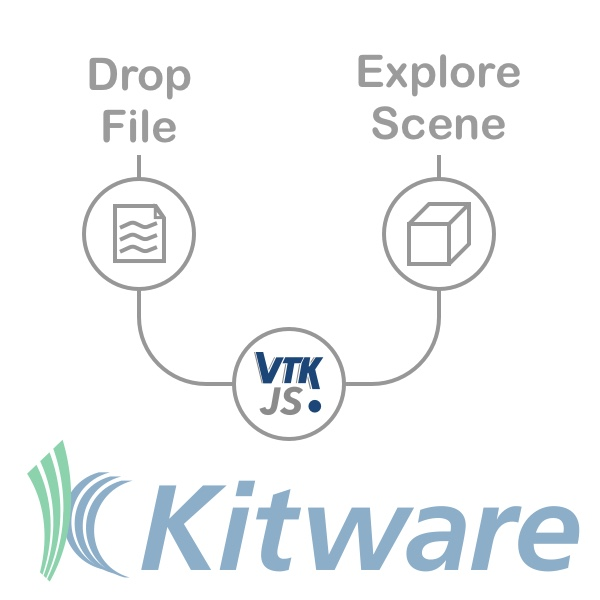

In [32]:
from nilearn.surface import load_surf_data

sulc_left = load_surf_data(fsaverage.sulc_left)
sulc_right = load_surf_data(fsaverage.sulc_right)

def sulc_shade(sulc):
    # 고랑(sulcus)은 어둡게, 이랑(gyrus)은 밝게 — 0.45~1.0 사이 밝기 배수
    norm = (sulc - sulc.min()) / (sulc.max() - sulc.min())
    return 0.45 + 0.55 * (1 - norm)

def faces_to_pv(faces):
    tri = faces[:, :3]
    return np.hstack([np.full((tri.shape[0], 1), 3), tri]).astype(np.int64).ravel()

left_faces_pv = faces_to_pv(left_faces)
right_faces_pv = faces_to_pv(right_faces)

def cortex_mesh(hemisphere, group):
    coords = left_coords if hemisphere == "LH" else right_coords_offset
    faces_pv = left_faces_pv if hemisphere == "LH" else right_faces_pv
    sulc = sulc_left if hemisphere == "LH" else sulc_right
    values = annot_values(hemisphere, group)
    values_filled = np.nan_to_num(values, nan=0.0)  # NaN 영역도 주름 음영은 보이게
    rgba = red_cmap(np.clip(values_filled / vmax, 0, 1))
    shade = sulc_shade(sulc)
    rgb = np.clip(rgba[:, :3] * shade[:, None], 0, 1)
    mesh = pv.PolyData(coords, faces_pv)
    mesh["rgb"] = (rgb * 255).astype(np.uint8)
    return mesh

def add_subcortical_glyphs(plotter, group):
    row_by_roi = burden_df[burden_df.group.eq(group)].set_index("roi")["mean_burden_z"].to_dict()
    for roi, (x, y, z, label) in SUBCORTICAL_COORDS.items():
        value = row_by_roi.get(roi, 0.0)
        radius = 3.0 + 6.0 * min(max(value, 0), 3) / 3
        sphere = pv.Sphere(radius=radius, center=(offset_x(x), y, z))
        color = red_cmap(min(max(value, 0), vmax) / vmax if vmax > 0 else 0)
        plotter.add_mesh(sphere, color=to_hex(color), pbr=True, metallic=0.15, roughness=0.25, specular=0.5)

def add_colorbar_proxy(plotter):
    # rgb 모드는 자체 컬러바가 없어서, 투명한 점 하나로 컬러바만 별도로 만든다.
    proxy = pv.PolyData(np.array([[0.0, 0.0, 0.0]]))
    proxy["burden"] = np.array([0.0])
    plotter.add_mesh(proxy, scalars="burden", cmap="Reds", clim=[0, vmax], opacity=0.0,
                      show_scalar_bar=True, scalar_bar_args={"title": "피질 얇아짐 부담(Z)", "color": "white"})

all_pts = np.vstack([left_coords, right_coords_offset])
center = all_pts.mean(axis=0)
extent = float(np.ptp(all_pts, axis=0).max())
camera_pos = (center[0], center[1] - extent * 1.6, center[2] + extent * 0.35)

pl = pv.Plotter(shape=(1, 3), off_screen=True, window_size=(1500, 560), border=False)
for i, group in enumerate(GROUPS):
    pl.subplot(0, i)
    pl.set_background("black")
    pl.remove_all_lights()  # 기본 조명 위에 계속 더해지던 것을 리셋
    pl.add_mesh(cortex_mesh("LH", group), scalars="rgb", rgb=True, smooth_shading=True,
                ambient=0.28, diffuse=0.8, specular=0.12, specular_power=8)
    pl.add_mesh(cortex_mesh("RH", group), scalars="rgb", rgb=True, smooth_shading=True,
                ambient=0.28, diffuse=0.8, specular=0.12, specular_power=8)
    add_subcortical_glyphs(pl, group)
    if i == len(GROUPS) - 1:
        add_colorbar_proxy(pl)
    pl.add_light(pv.Light(position=(center[0] + extent, center[1] - extent * 1.2, center[2] + extent),
                           light_type="scene light", intensity=0.8))
    pl.add_light(pv.Light(position=(center[0] - extent, center[1] - extent * 0.6, center[2] + extent * 0.3),
                           light_type="scene light", intensity=0.6))
    pl.camera_position = [tuple(camera_pos), tuple(center), (0, 0, 1)]
    try:
        pl.enable_shadows()
    except Exception:
        pass

pl.link_views()

output_path = FIG_DIR / "group_bag_3d_pyvista.html"
pl.export_html(str(output_path))
print("PyVista 3D HTML 저장:", output_path)

import html as _html
scene_html = output_path.read_text(encoding="utf-8")
wrapper_html = f"""
<div style="background:#000;padding:10px;border-radius:8px;">
  <div style="display:flex;color:#fff;font-family:sans-serif;font-size:15px;font-weight:600;margin-bottom:4px;">
    <div style="flex:1;text-align:center;">CN (기준)</div>
    <div style="flex:1;text-align:center;">MCI</div>
    <div style="flex:1;text-align:center;">AD</div>
  </div>
  <iframe srcdoc="{_html.escape(scene_html)}" style="width:100%;height:560px;border:none;background:black;"></iframe>
  <div style="color:#ddd;font-family:sans-serif;font-size:12.5px;line-height:1.6;padding:8px 4px 2px;">
    <b>피질 색상(Reds):</b> 진한 빨강일수록 CN 대비 피질이 더 얇아진 부담(Z-score)이 큼 (고랑·이랑 음영은 실제 해부학적 깊이).<br>
    <b>구슬(피질하 구조, 근사 위치 표식):</b> 해마·편도체·시상·조가비핵·가쪽뇌실·3뇌실·4뇌실·뇌간 —
    구슬이 크고 진할수록 해당 구조의 위축(회색질)/확장(뇌실) 부담(Z-score)이 큼. 실제 세그멘테이션 형상이 아님.
  </div>
</div>
"""
from IPython.display import HTML, display as ipy_display
ipy_display(HTML(wrapper_html))

##9-1. 3D 저장

In [ ]:
from google.colab import files
files.download(str(output_path))

In [ ]:
# 1) 가상 디스플레이 준비 (최초 1회, 20~30초 정도 걸릴 수 있음)
pv.start_xvfb()

# 2) 정지 이미지 저장
pl.screenshot(str(FIG_DIR / "group_bag_3d_pyvista.png"))
files.download(str(FIG_DIR / "group_bag_3d_pyvista.png"))

In [ ]:
# 3) 360도 회전 동영상(mp4) 저장 — imageio-ffmpeg 필요
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "imageio", "imageio-ffmpeg"], check=True)

video_path = FIG_DIR / "group_bag_3d_pyvista.mp4"
pl.open_movie(str(video_path), framerate=24)
for _ in range(120):          # 120프레임, 3도씩 = 360도 한 바퀴
    pl.camera.azimuth(3)
    pl.render()
    pl.write_frame()
pl.close()
files.download(str(video_path))

## 10. 결론

본 연구에서는 ADNI 데이터셋을 기반으로 데이터 중복을 제거한 Index MRI 및 Ridge Regression 모델을 활용하여 보정된 뇌 연령 갭(Bias-Corrected BAG) 추정 파이프라인을 구축했다.

특히 3D 뇌 표면 매핑 시각화를 통해 정상(CN) < 경도인지장애(MCI) < 알츠하이머병(AD) 집단으로 갈수록 BAG 값이 유의미하게 증가함을 확인했다(위 9절 요약표 및 ANCOVA 참조). 위축이 가속화된 주된 취약 부위는 해마(Hippocampus) 용적 감소, 내후각피질(Entorhinal cortex) 및 측두엽(Temporal lobe) 피질 두께 감소, 뇌실(Ventricle) 확장으로 나타났다(위 8절 지역별 노화 부담 참조).

결론적으로, 편향이 보정된 3D 뇌 연령 BAG 파이프라인은 신경퇴행성 질환의 초기 진단 및 진행 예측을 위한 직관적이고 표준화된 임상 보조 도구로 활용될 잠재력이 있다.

**한계**: (1) 교육이수는 현재 입력 파일(FreeSurfer 구조 ROI)에 없어 이번 실행에는 포함되지 않았다 — ADNIMERGE 인구통계 자료를 RID·방문일 기준으로 병합하면 자동 반영되도록 코드를 작성해 두었다. (2) 피질하 구조 3D 글리프는 실제 세그멘테이션 메시가 아닌 근사 위치 표식이다. (3) 본 파이프라인은 연구용 집단 수준 분석이며 개별 환자의 확정적 임상 진단 도구로 사용해서는 안 된다.